# LangGraph QuickStart

LangGraph는 상태 기반 멀티 액터 애플리케이션을 구축하기 위한 프레임워크입니다.

## 구현 기능

- 상태 관리 기반 챗봇
- 외부 도구 연동 (Tavily Search)
- 메모리 및 체크포인트
- Human-in-the-Loop
- 상태 커스터마이징
- 상태 이력 관리

## 환경 설정

LangGraph를 사용하기 위해 필요한 환경 변수와 로깅을 설정합니다. `.env` 파일에 API 키를 저장하고, LangSmith를 통해 실행 과정을 추적할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangChain-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


---

## 기본 챗봇 구축

메시지 기반 챗봇을 StateGraph로 구성합니다. StateGraph는 LangGraph의 핵심 구성 요소로, 노드와 엣지를 연결하여 상태 기반 워크플로우를 정의합니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api.md)

### 구성 요소

| 구성 요소 | 설명 |
|----------|------|
| StateGraph | 전체 워크플로우 흐름을 정의하는 그래프 |
| State | 그래프 실행 중 데이터를 저장하는 상태 객체 |
| Node | 실제 작업을 수행하는 함수 (예: LLM 호출) |
| Edge | 노드 간 실행 경로를 연결 |
| Compile/Invoke | 그래프를 실행 가능한 형태로 변환 및 호출 |

아래 코드는 State 타입을 정의하고 StateGraph 인스턴스를 생성합니다.

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의: 챗봇의 상태를 나타내는 타입
class State(TypedDict):
    """챗봇의 상태를 정의하는 타입

    messages: 대화 메시지 리스트
    - add_messages 함수를 통해 새 메시지가 추가됨 (덮어쓰기가 아닌 추가)
    """

    messages: Annotated[list, add_messages]


# StateGraph 생성
graph_builder = StateGraph(State)

print("StateGraph 생성 완료!")
print("State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.")

StateGraph 생성 완료!
State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.


### LLM 설정

LangGraph의 노드에서 사용할 언어 모델을 설정합니다. `init_chat_model` 함수를 사용하면 다양한 제공자(OpenAI, Anthropic 등)의 모델을 통일된 인터페이스로 사용할 수 있습니다.

아래 코드는 OpenAI의 GPT-5.4 모델을 초기화합니다.

In [3]:
from langchain.chat_models import init_chat_model

# 모델 식별자 문자열을 사용한 간단한 방법
llm = init_chat_model("openai:gpt-5.4")

### 챗봇 노드 추가

노드는 그래프에서 실제 작업을 수행하는 함수입니다. 챗봇 노드는 현재 상태의 메시지를 받아 LLM에 전달하고, 응답을 새 메시지로 추가하여 반환합니다.

`add_node` 메서드의 첫 번째 인자는 노드의 고유 이름이고, 두 번째 인자는 호출될 함수입니다.

아래 코드는 챗봇 노드 함수를 정의하고 그래프에 추가합니다.


# 아래 코드 정확한 설명

llm.invoke(state["messages"])는 state에 쌓인 전체 메시지 이력을 모델 입력으로 전달해요. 그래서 모델이 앞선 대화 맥락을 참고할 수 있습니다.
return {"messages": [response]}는 그래프 상태에 반영할 새 메시지 업데이트를 반환해요. 여기서는 모델의 응답 하나만 반환합니다.
messages에 add_messages 리듀서가 설정돼 있으면 LangGraph가 그 응답을 기존 메시지 목록에 추가해요. 따라서 그래프 실행 후 상태에는 기존 대화와 새 응답이 함께 남습니다.
즉, 노드가 대화 전체를 다시 반환하는 게 아니라, 새 응답만 반환하고 리듀서가 기존 이력에 누적하는 구조예요.


In [4]:
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 받아 LLM에 전달하고,
    응답을 새 메시지로 추가하여 반환합니다.
    """
    # LLM을 호출하여 응답 생성
    response = llm.invoke(state["messages"])

    # 응답을 메시지 리스트에 추가하여 반환
    return {"messages": [response]}


# 그래프에 노드 추가
# 첫 번째 인자: 노드의 고유 이름
# 두 번째 인자: 노드가 사용될 때 호출될 함수
graph_builder.add_node("chatbot", chatbot)

### 엣지 설정

엣지는 노드 간의 실행 흐름을 정의합니다. `START`는 그래프 실행의 시작점이고, `END`는 종료점입니다. 모든 그래프는 반드시 시작점과 종료점을 가져야 합니다.

아래 코드는 실행 경로(START → chatbot → END)를 설정합니다.

In [5]:
# 진입점: 그래프 실행이 시작되는 지점
graph_builder.add_edge(START, "chatbot")

# 종료점: 그래프 실행이 끝나는 지점
graph_builder.add_edge("chatbot", END)

print("진입점과 종료점 설정 완료!")
print("실행 흐름: START → chatbot → END")

진입점과 종료점 설정 완료!
실행 흐름: START → chatbot → END


### 그래프 컴파일

StateGraph를 정의한 후에는 반드시 `compile()` 메서드를 호출하여 실행 가능한 형태로 변환해야 합니다. 컴파일 과정에서 노드 간 연결이 검증되고, 실행 순서가 결정됩니다.

아래 코드는 정의한 그래프를 컴파일하고 실행 가능한 객체를 반환합니다.

In [6]:
# 그래프 컴파일
graph = graph_builder.compile()

print("그래프 컴파일 완료!")

그래프 컴파일 완료!


### 그래프 시각화

컴파일된 그래프의 구조를 시각적으로 확인할 수 있습니다. `langchain_teddynote` 패키지의 `visualize_graph` 함수를 사용하면 노드와 엣지의 연결 상태를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

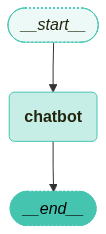

In [7]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

### 그래프 실행

`stream_graph` 함수를 사용하면 그래프 실행 결과를 스트리밍 방식으로 출력할 수 있습니다. `RunnableConfig`를 통해 재귀 깊이 제한(`recursion_limit`)과 스레드 식별자(`thread_id`)를 설정합니다.

아래 코드는 Config를 설정하고 사용자 입력을 준비합니다.

In [8]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain.messages import HumanMessage

# Config 설정(recursion_limit: 재귀 깊이 제한, thread_id: 스레드 아이디)
config = RunnableConfig(recursion_limit=20, thread_id="abc123")

In [9]:

inputs = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
}

 # 타입 힌트 추가

inputs: State = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
    }

# 그래프 스트리밍
stream_graph(graph, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 물론이죠.  
**LangGraph**는 **LLM(대규모 언어 모델) 기반 애플리케이션을 “그래프 구조”로 설계하고 실행할 수 있게 해주는 프레임워크**입니다. 특히 **에이전트(agent)**, **상태(state)**, **분기(branching)**, **반복(loop)**, **멀티스텝 워크플로우**를 만들 때 유용합니다.

간단히 말하면:

- **LangChain**이 LLM 앱의 다양한 구성 요소를 연결하는 도구라면,
- **LangGraph**는 그 흐름을 **그래프 형태로 더 정교하게 제어**할 수 있게 해줍니다.

---

## 1. 왜 LangGraph를 쓰나요?

일반적인 LLM 체인은 보통 이렇게 생깁니다:

1. 사용자 입력 받기
2. 프롬프트 구성
3. 모델 호출
4. 결과 반환

하지만 실제 서비스에서는 더 복잡해집니다.

예:
- 먼저 질문 분류
- 필요하면 검색 수행
- 검색 결과가 부족하면 다시 검색
- 특정 조건이면 사람 승인 요청
- 승인 후 최종 응답 생성

이런 흐름은 단순한 “직선형 체인”보다  
**조건 분기**, **루프**, **상태 저장**이 필요합니다.

LangGraph는 이런 문제를 해결하기 위해 등장했습니다.

---

## 2. 핵심 개념

### 2-1. Graph
작업 흐름을 **노드(node)**와 **엣지(edge)**로 표현합니다.

- **노드**: 하나의 작업 단위  
  예) 모델 호출, 검색, 검증, 도구 실행
- **엣지**: 다음에 어느 노드로 갈지 연결

즉, “어떤 단계들을 어떤 규칙으로 이어붙일지”를 그래프로 정의합니다.

---

### 2-2. State
LangGraph의 아주 중요한 개념입니다.

각 단계에서 필요한 데이터를 **공유 상태(state)**에 저장하고 업데이트합니다.

예를 들면 state에 이런 값들이 들어갈 수 있습

---

## 도구(Tools) 추가

외부 검색 도구를 통합하여 실시간 정보를 조회할 수 있는 챗봇을 만듭니다. LangGraph는 LLM이 외부 도구를 호출하고 그 결과를 활용하는 워크플로우를 쉽게 구성할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Tool Integration](https://docs.langchain.com/oss/python/langgraph/tool-integration.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Tool Binding | LLM에 사용 가능한 도구를 연결하는 과정 |
| Tool Node | 실제 외부 API를 호출하는 노드 |
| Conditional Edges | LLM 응답에 따라 도구 사용 여부를 자동 분기 |

아래 코드는 간단한 덧셈 도구를 정의합니다.

In [10]:
# 공유
from langchain.tools import tool


@tool
def add(a: int, b: int):
    "두 숫자를 더합니다."
    return a + b

In [11]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

# Tavily 검색 도구 설정
researchtool = TavilySearch(max_results=2)
tools = [researchtool, add]

# 도구 테스트
result = researchtool.invoke("LangGraph란 무엇인가요?")
print(f"검색 결과 수: {len(result['results'])}개")
print(f"첫 번째 결과 제목: {result['results'][0]['title']}")

검색 결과 수: 2개
첫 번째 결과 제목: LangGraph란 무엇인가요? | IBM


### 도구 사용 그래프 구성

기본 챗봇 흐름에 도구 호출 경로를 추가합니다. LLM이 도구 호출을 요청하면 "tools" 노드로 이동하고, 도구 실행 후 다시 챗봇으로 돌아오는 순환 구조(chatbot ⇄ tools)를 구성합니다.

아래 코드는 LLM에 도구를 바인딩합니다.

In [12]:
llm_with_tools = llm.bind_tools(tools)

In [13]:
ret1 = llm_with_tools.invoke("LangGraph 가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph 가 뭐야? 검색해서 알려줘")

In [14]:
print(ret1.content)

LangGraph는 **LLM 애플리케이션을 그래프(graph) 구조로 설계·실행하는 프레임워크**예요.  
쉽게 말하면, 단순한 “프롬프트 → 답변”을 넘어서:

- 여러 단계로 나뉜 작업
- 도구 호출
- 조건 분기
- 반복 루프
- 상태 저장
- 사람의 승인(human-in-the-loop)

같은 걸 **노드와 엣지로 연결해서 만드는 오케스트레이션 도구**입니다.

보통 **LangChain 생태계** 안에서 많이 쓰이고, 특히 **에이전트(agent) 워크플로우**를 만들 때 자주 언급돼요.

## 비유하면
- **LangChain**: LLM 기능을 조립하는 부품 상자
- **LangGraph**: 그 부품들이 어떤 순서와 조건으로 움직일지 설계하는 상태 머신/워크플로우 엔진

## 왜 쓰냐
일반적인 체인은 보통 선형 흐름에 강한데, 실제 서비스는 종종 이런 요구가 있어요:

- 답변 전에 검색을 할지 말지 판단
- 검색 결과가 부족하면 다시 검색
- 특정 조건이면 사람 검토 요청
- 실패하면 다른 경로로 재시도
- 이전 대화 상태를 계속 유지

이런 건 **그래프 기반 흐름**이 훨씬 표현하기 쉬워요.

## 핵심 개념
### 1. State
작업 중간 결과를 저장하는 상태입니다.  
예:
- 사용자 질문
- 검색 결과
- 모델의 중간 추론 결과
- 최종 응답

### 2. Node
그래프의 각 작업 단위예요.  
예:
- 질문 분류
- 웹 검색
- 문서 요약
- 답변 생성

### 3. Edge
노드 사이의 연결입니다.  
단순히 다음 단계로 가거나, 조건에 따라 다른 노드로 분기할 수 있어요.

### 4. Conditional Routing
상태를 보고 다음 노드를 다르게 선택합니다.  
예:
- 정보가 충분하면 답변 생성
- 부족하면 재검색

### 5. Persistence / Checkpointing
실행 상태를 저장해두고 이어서 진행할 수 있어요.  
긴 작업, 멀티턴 대화, 승인 플로우에 유용합니다.

## 어떤 경우에 유용한가
La

In [15]:
from langchain_teddynote.messages import display_message_tree

display_message_tree(ret1)

    content: "LangGraph는 **LLM 애플리케이션을 그래프(graph) 구조로 설계·실행하는 프레임워크**예요.  
쉽게 말하면, 단순한 “프롬프트 → 답변”을 넘어서:

- 여러 단계로 나뉜 작업
- 도구 호출
- 조건 분기
- 반복 루프
- 상태 저장
- 사람의 승인(human-in-the-loop)

같은 걸 **노드와 엣지로 연결해서 만드는 오케스트레이션 도구**입니다.

보통 **LangChain 생태계** 안에서 많이 쓰이고, 특히 **에이전트(agent) 워크플로우**를 만들 때 자주 언급돼요.

## 비유하면
- **LangChain**: LLM 기능을 조립하는 부품 상자
- **LangGraph**: 그 부품들이 어떤 순서와 조건으로 움직일지 설계하는 상태 머신/워크플로우 엔진

## 왜 쓰냐
일반적인 체인은 보통 선형 흐름에 강한데, 실제 서비스는 종종 이런 요구가 있어요:

- 답변 전에 검색을 할지 말지 판단
- 검색 결과가 부족하면 다시 검색
- 특정 조건이면 사람 검토 요청
- 실패하면 다른 경로로 재시도
- 이전 대화 상태를 계속 유지

이런 건 **그래프 기반 흐름**이 훨씬 표현하기 쉬워요.

## 핵심 개념
### 1. State
작업 중간 결과를 저장하는 상태입니다.  
예:
- 사용자 질문
- 검색 결과
- 모델의 중간 추론 결과
- 최종 응답

### 2. Node
그래프의 각 작업 단위예요.  
예:
- 질문 분류
- 웹 검색
- 문서 요약
- 답변 생성

### 3. Edge
노드 사이의 연결입니다.  
단순히 다음 단계로 가거나, 조건에 따라 다른 노드로 분기할 수 있어요.

### 4. Conditional Routing
상태를 보고 다음 노드를 다르게 선택합니다.  
예:
- 정보가 충분하면 답변 생성
- 부족하면 재검색

### 5. Persistence / Checkpointing
실행 상태를 저장해두고 이어서 진행할 수 있어요.  
긴 작업, 멀티턴 대화, 승인 플로우에 유용합니다.

## 

In [16]:
display_message_tree(ret2)

    content: ""
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 59
            prompt_tokens: 1301
            total_tokens: 1360
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0, "text_tokens": None}
            prompt_tokens_details: {"audio_tokens": 0, "cache_write_tokens": None, "cached_tokens": 0, "image_tokens": None, "text_tokens": None}
        model_provider: "openai"
        model_name: "gpt-5.4-2026-03-05"
        system_fingerprint: None
        id: "chatcmpl-EScCItITqYe8izOygh8agjoIz0cWY"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "lc_run--01a0e171-bdea-71d2-98c9-33264047dce8-0"
    tool_calls:
        index [0]
            name: "tavily_search"
            args:
                query: "LangGraph what is LangGraph official do

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의 (동일)
class State(TypedDict):
    messages: Annotated[list, add_messages]


# State를 담는 새로운 그래프 빌더 생성
builder = StateGraph(State)

# LLM에 도구 바인딩 - LLM이 도구를 사용할 수 있도록 설정
# 앞에서 llm = init_chat_model("openai:gpt-5.4")로 초기화한 LLM을 사용
# 앞에서 정의한 tools 리스트를 사용하여 LLM에 도구를 바인딩
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    """도구를 사용할 수 있는 챗봇 노드"""
    # 도구가 바인딩된 LLM 호출
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 노드 추가 (첫번째 인자: 노드 이름, 두번째 인자: 노드 함수)
builder.add_node("chatbot", chatbot)

# ToolNode 정의 - 도구를 실행하는 노드
tool_node = ToolNode(tools=tools)

# 툴 노드 추가 (첫번째 인자: 노드 이름, 두번째 인자: 노드 함수)
builder.add_node("tools", tool_node)

### 조건부 라우팅

`tools_condition`이 마지막 AI 메시지의 `tool_calls` 존재 여부를 확인해 경로를 분기합니다.

### tools_condition 동작

`tool_calls` 존재 시 "tools"로, 없으면 "\_\_end\_\_"로 분기합니다.

```python
def tools_condition(state) -> Literal["tools", "__end__"]:
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"
```

In [ ]:
# 조건부 엣지 추가
# tools_condition은 메시지에 tool_calls가 있으면 "tools"로,
# 없으면 END로 라우팅합니다
# 그치 이 add_conditonal_edges도 StateGraph에 정의된 메서드라서, StateGraph를 상속받은 builder에서 호출 가능
builder.add_conditional_edges("chatbot", tools_condition,)  
# 사전 정의된 조건 함수 사용
# Literal["tools", "__end__"]

# 도구 실행 후 다시 챗봇으로 돌아가기
builder.add_edge("tools", "chatbot")

# 시작점 설정
builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph_with_tools = builder.compile()

### 그래프 시각화

도구가 연결된 그래프의 구조를 시각화합니다. chatbot 노드에서 조건에 따라 tools 노드로 분기하는 구조를 확인할 수 있습니다.

아래 코드는 도구가 연결된 그래프를 시각화합니다.

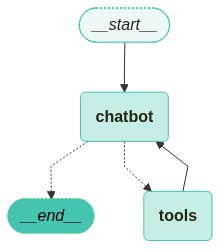

In [19]:
# 그래프 시각화
visualize_graph(graph_with_tools)

### 도구 사용 테스트

Tavily 검색 도구를 활용하여 최신 정보를 검색하는 테스트를 수행합니다. LLM이 질문에 답하기 위해 필요하다고 판단하면 자동으로 검색 도구를 호출합니다.

아래 코드는 2025년 LangGraph 사용 사례에 대한 검색을 수행합니다.

In [20]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="2025년 LangGraph 사용 사례 알려주세요.")]
    },
    config=config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{'error': ConnectionError(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')))}
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "2025 LangGraph use cases examples LangGraph agents workflows case studies", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "How Build.inc used LangGraph to launch a Multi-Agent Architecture for automating critical CRE workflows for Data Center Development.", "url": "https://www.langchain.com/blog/how-build-inc-used-langgraph-to-launch-a-multi-agent-architecture-for-automating-critical-cre-workflows-for-data-center-development", "content": "Try LangSmith\n\nGet a demo\n\nCase Studies\n\n# How Build.inc used LangGraph to launch a Multi-Agent 

---

## 메모리 추가

세션 간 사용자 정보를 유지하는 영구 상태 관리를 추가합니다. 메모리 기능을 통해 챗봇이 이전 대화 내용을 기억하고, 사용자별로 개인화된 응답을 제공할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Persistence](https://docs.langchain.com/oss/python/langgraph/persistence.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Checkpointer | 그래프 실행 중 상태를 저장하고 복원하는 컴포넌트 |
| Thread ID | 동일 세션을 식별하는 고유 식별자 |
| User ID | 사용자별 장기 기억을 관리하는 식별자 |
| Persistent State | 누적된 대화 이력 기반의 컨텍스트 |

아래 코드는 메모리 추출을 위한 Pydantic 모델과 추출기를 정의합니다.

In [62]:
from typing import List, Optional, Any
from datetime import datetime
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
import os


# Pydantic 모델 정의
class MemoryItem(BaseModel):
    """개별 메모리 아이템"""

    key: str = Field(description="메모리 키 (예: user_name, preference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description="카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0.0, le=1.0)


class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )


# 기본 시스템 프롬프트
DEFAULT_SYSTEM_PROMPT = """You are an expert memory extraction assistant. Your task is to extract important information from user conversations and convert them into structured key-value pairs for long-term memory storage.

Extract ALL relevant information from the conversation, including:
- Personal information (name, age, location, occupation, etc.)
- Preferences and interests
- Relationships and social connections
- Important facts or events mentioned
- Opinions and beliefs
- Goals and aspirations
- Any other notable information

For each piece of information:
1. Create a concise, searchable key
2. Store the complete value
3. Categorize appropriately
4. Assess importance (1-5 scale)
5. Evaluate extraction confidence (0.0-1.0)"""


def create_memory_extractor(
    model: Optional[str] = "openai:gpt-5.4",
    system_prompt: Optional[str] = None,
) -> Any:
    """메모리 추출기를 생성합니다.

    Args:
        model_name: 사용할 언어 모델. None일 경우 기본 ChatOpenAI 모델 사용
        system_prompt: 시스템 프롬프트. None일 경우 기본 프롬프트 사용

    Returns:
        메모리 추출 체인
    """
    # Output Parser 생성
    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)

    # 시스템 프롬프트 설정
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT

    # 전체 프롬프트 템플릿 구성
    template = f"""{system_prompt}

    User Input: {{input}}

    {{format_instructions}}

    Remember to:
    - Extract multiple memory items if the conversation contains various pieces of information
    - Use clear, consistent key naming conventions
    - Preserve context in values when necessary
    - Be comprehensive but avoid redundancy
    """

    # 프롬프트 생성
    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={
            "format_instructions": memory_parser.get_format_instructions()
        # get_format_instructions()는 우리가 직접 정의한 함수가 아니라, LangChain의 PydanticOutputParser 클래스에 이미 들어 있는 메서드
        },
    )

    # 모델 설정
    model = init_chat_model(model)

    # 메모리 추출 체인 생성
    memory_extractor = prompt | model | memory_parser

    return memory_extractor

In [63]:
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.store.base import BaseStore
from langchain_openai import ChatOpenAI

from langchain_teddynote.memory import create_memory_extractor
import uuid

model = init_chat_model("openai:gpt-5.4")
memory_extractor = create_memory_extractor(model="openai:gpt-5.4")


def call_model(
    state: MessagesState,
    config: RunnableConfig,
    *,
    store: BaseStore,
) -> dict[str, Any]:
    """LLM 모델을 호출하고 사용자 메모리를 관리합니다.

    Args:
        state (MessagesState): 메시지를 포함하는 현재 상태
        config (RunnableConfig): 실행 가능 구성
        store (BaseStore): 메모리 저장소
    """
    # 마지막 메시지에서 user_id 추출
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)

    print(namespace)

    # 유저의 메모리 검색
    memories = store.search(namespace, query=str(state["messages"][-1].content))
    info = "\n".join([f"{memory.key}: {memory.value}" for memory in memories])
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # 사용자가 기억 요청 시 메모리 저장
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        result = memory_extractor.invoke({"input": str(state["messages"][-1].content)})
        for memory in result.memories:
            print(memory)
            print("-" * 100)
            store.put(namespace, str(uuid.uuid4()), {memory.key: memory.value})

    # LLM 호출
    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}

## 위 코드의 기억 저장·검색 흐름

```text
사용자 발화
"나는 유망기술 조기식별 연구를 하고 있어."
       │
       ├─ 기억 추출기 (`memory_extractor`)
       │    └─ 문장을 구조화
       │       {"research_topic": "유망기술 조기식별"}
       │
       └─ `store.put()`
            └─ 저장


이후의 사용자 발화
"유망기술 연구가 잘 안 풀려."
       │
       └─ `store.search(query=사용자 발화)`
            └─ 이미 저장된 관련 기억을 찾아 반환
               {"research_topic": "유망기술 조기식별"}

result.memories의 예시 

```text
[  
    MemoryItem(  
        key="explanation_preference",  
        value="기초부터 설명받는 것을 선호함",  
        category="preference",  
        importance=4,  
        confidence=0.95,  
    )  
]  

### 실행 흐름

1. 마지막 사용자 메시지 확인  
   ↓  
2. `"remember"` 포함 여부 확인  
   ↓  
3. 포함된 경우: 기억 추출 → 기억 저장  
   ↓  
4. 기존 대화 + 검색된 기존 기억을 모델에 전달  
   ↓  
5. AI 답변 생성  
   ↓  
6. 답변을 `messages` 상태에 추가

In [23]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

# 그래프 빌드
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

# 메모리 체크포인터 생성
# 실제 프로덕션에서는 PostgresSaver 사용 권장
memory_saver = InMemorySaver()
memory_store = InMemoryStore()

# 그래프 컴파일
graph_with_memory = builder.compile(
    checkpointer=memory_saver,
    store=memory_store,
)

Q1. MessagesState는 어디서 정의했던 class지? 상태의 모양을 정의한 class가 들어가야하는 건 맞지?

A1. yes. 앞에서 직접 작성한 State와 역할은 비슷합니다. 차이는 State는 노트북에서 직접 정의했고, MessagesState는 LangGraph가 제공하는 messages 중심의 기본 상태 타입이라는 점이에요. 

Q2. 여기서 postgressaver 사용 권장은 뭐야? 

A2. InMemorySaver: 체크포인트가 프로세스 메모리에만 있어요. 학습·테스트에는 간편하지만, 커널이나 서버가 종료되면 저장한 상태가 사라집니다.
PostgresSaver: 체크포인트를 PostgreSQL 데이터베이스에 저장하므로, 프로세스가 재시작되어도 상태를 유지할 수 있어요. 여러 실행 환경에서 공유하거나 운영 환경에서 지속적으로 보관할 때 적합합니다.

In [24]:
from langchain_teddynote.messages import stream_graph


def run_graph(
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저] {msg}")
    stream_graph(
        graph_with_memory,
        inputs={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )
    print()

q1. msg는 내가 어디서 정의했던 건가? 
a1. 아니요. msg를 함수 바깥에서 미리 정의한 게 아니라, run_graph의 매개변수로 선언한 거예요 *(함수 정의).*

예를 들어 run_graph("안녕? 내 이름은 테디야", "1", "someone")을 호출하면, 첫 번째 인자가 함수 안의 msg가 됩니다. 실제로는 이 값을 출력하고, messages 목록에 담아 그래프에 전달해요(호출 예시).

즉, 호출하는 쪽이 msg 값을 넘기고, 함수 안에서는 그 값을 받아 사용하는 구조입니다. msg는 이 함수의 매개변수 이름이고, 그래프 상태의 messages 키와는 별개예요.

q2. stream_graph()가 필요로 하는 인자가 뭐였지(langchain_teddynote.messages에서 가져온 출력 보조 함수임)

a2. 

```text
stream_graph(
    graph_with_memory,  # 1. 실행할 그래프
    inputs={            # 2. 그래프에 새로 넣을 입력
        "messages": [
            {"role": "user", "content": msg}
        ]
    },
    config=config,      # 3. 실행 설정
)

inputs={"messages": [{"role": "user" 

여기서 user는 변수가 아니다. 

In [25]:
# 메시지, thread_id, user_id 전달
run_graph("안녕? 내 이름은 테디야", "1", "someone")


[유저] 안녕? 내 이름은 테디야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕 테디! 만나서 반가워 😊  
무엇을 도와줄까?


```text
출력에는 서로 다른 출처의 내용이 섞여 있어요.

[유저] ... — run_graph()에서 print()한 입력값입니다.
('memories', 'someone') — call_model()의 print(namespace) 결과예요.
Node: call_model과 구분선 — stream_graph()가 그래프 실행을 보여주며 출력한 로그입니다.
“안녕, 테디! 반가워…” — 모델이 생성한 답변입니다.
모델 호출은 call_model() 안에서 이뤄져요. 검색한 사용자 기억을 시스템 메시지에 넣고, 그 뒤에 현재 대화 메시지를 붙여 model.invoke()에 전달합니다(기억 검색과 모델 호출). 입력에 “내 이름은 테디야”가 있었으므로 모델이 그 맥락을 바탕으로 테디라고 부른 거예요. 이전에 저장된 관련 기억이 있다면 그것도 답변에 영향을 줄 수 있습니다.

별도의 출력 형식을 지정하지 않았기 때문에 모델은 일반적인 대화 문장으로 답합니다. stream_graph()는 답변 문구를 정하는 함수가 아니라, 그래프 실행 내용을 화면에 보여주는 보조 함수예요.

In [26]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "1", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디! 😊


In [27]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "2", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
아직 이름을 알려주지 않으셨어요.  
원하시면 제가 기억할 이름을 알려주세요!


# 정리 

```text
이 호출을 기준으로 클래스와 함수의 역할을 따라가면 다음과 같아요.

호출부 → run_graph()
msg, thread_id, user_id를 받습니다. 입력 메시지를 그래프에 넘기고, config에는 thread_id와 user_id를 담아요. 이 예시의 thread_id는 "1someone"으로 만들어지고, user_id는 "someone" 그대로 전달됩니다. 01-QuickStart-LangGraph-Tutorial.ipynb:1181-1205

MessagesState와 그래프 → call_model() 실행
StateGraph(MessagesState)로 만든 그래프가 messages를 포함한 상태를 관리하고, call_model()이 그 상태와 config, store를 받아 처리합니다. InMemoryStore는 그래프를 컴파일할 때 store로 연결돼요. 01-QuickStart-LangGraph-Tutorial.ipynb:1029-1038 01-QuickStart-LangGraph-Tutorial.ipynb:1142-1155

call_model() → 해당 사용자의 기억 검색
config에서 user_id를 꺼내 ("memories", user_id)라는 저장 공간을 만듭니다. 따라서 "someone"의 기억은 ("memories", "someone") 아래에서 검색돼요. 같은 사용자는 다른 thread_id로 대화해도 이 저장 공간을 공유합니다.

메시지에 remember가 있으면 → 추출하고 저장
MemoryItem과 ExtractedMemories가 기억 데이터의 구조를 정의하고, memory_extractor가 대화에서 저장할 정보를 뽑습니다. 그 결과를 같은 사용자 namespace에 store.put()으로 기록해요. 01-QuickStart-LangGraph-Tutorial.ipynb:916-958 01-QuickStart-LangGraph-Tutorial.ipynb:1052-1060

call_model() → 모델 호출 및 응답 반환
검색된 기억을 시스템 메시지에 포함하고 현재 messages와 함께 모델에 전달합니다. 응답은 {"messages": response} 형태로 그래프 상태에 반환돼요. stream_graph()가 그래프 실행 중 로그와 결과를 화면에 보여줍니다. 01-QuickStart-LangGraph-Tutorial.ipynb:1060-1068


### 장기 기억 저장

메시지에 `remember` 키워드 포함 시 장기 저장소에 정보를 기록합니다.

In [28]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 테디야 remember", "2", "someone")


[유저] 내 이름이 테디야 remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "user_name",
      "value": "테디",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 이름이 '테디'라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='user_name' value='테디' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠어요, 테디! 기억해둘게요.


### Thread 간 지속성

User ID 기반 장기 기억은 Thread가 달라도 유지됩니다.

In [29]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고 했더라?", "1004", "someone")


[유저] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디라고 하셨어요.


In [30]:
# 메시지, thread_id, user_id 전달
run_graph(
    "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "preference",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 AI Engineer이며, 취미로 Netflix 보기를 즐긴다고 언급함.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='preference' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠어요, 테디! 기억해둘게요:

- 직업: AI Engineer
- 취미: Netflix 보기

앞

In [31]:
# 다른 스레드에서 실행
run_graph("내 이름, 직업, 취미 알려줘", "100", "someone")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디님 정보는 다음과 같아요:

- 이름: 테디
- 직업: AI Engineer
- 취미: Netflix 보기


In [32]:
# 다른 user_id 로 실행한 경우
run_graph("내 이름, 직업, 취미 알려줘", "100", "other")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'other')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
저는 당신의 이름, 직업, 취미를 알 수 없어요. 아직 그런 정보를 받은 적이 없습니다.

원하시면 이렇게 알려주세요:
- 이름:
- 직업:
- 취미:

그러면 제가 기억해서 이후 대화에 반영할게요.


### State 확인

저장된 상태를 조회하여 메시지 이력과 체크포인트 정보를 확인합니다. `get_state` 메서드를 통해 현재 상태의 스냅샷을 가져올 수 있습니다.

아래 코드는 특정 Config에 대한 현재 상태 정보를 조회합니다.

In [33]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
snapshot = graph_with_memory.get_state(config)

print("현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    #hasattr <- has attribute, 객체가 특정 속성을 가지고 있는지 확인하는 함수
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f1ba389-0e61-6cfb-8001-dba35573f38d

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 테디님 정보는 다음과 같아요:

- 이름: 테디
- 직업: AI Engineer
- 취미: Netflix 보기


---

## Human-in-the-Loop

고위험 작업에 대해 인간 승인을 요청하는 흐름을 도입합니다. 중요한 결정이나 민감한 작업 수행 전에 사람의 확인을 받을 수 있어 AI 시스템의 안전성을 높입니다.

> 📖 **참고 문서**: [LangGraph Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| interrupt | 그래프 실행을 일시정지하고 외부 입력을 대기 |
| Command | 승인/거부 후 재개 명령을 전달하는 객체 |
| Human Approval | 사람이 검토하고 승인하는 워크플로우 |

아래 코드는 사람의 도움을 요청하는 도구를 정의합니다.

In [ ]:
from langchain.tools import tool
from langgraph.types import Command, interrupt


@tool
def human_assistance(query: str) -> str:
    """사람에게 도움 요청"""
    # 1. 그래프 멈춤 + 사람에게 "query"를 물어봄
    human_response = interrupt({"query": query})
    
    # 2. 사람이 응답하면, {"data": "...응답..."}이 돌아옴
    # 3. 그 중 "data" 필드만 추출해서 반환
    return human_response["data"]


### HITL 그래프 구성

`human_assistance` 도구를 사용하는 그래프를 구성합니다. 이 도구가 호출되면 `interrupt`로 실행이 중단되고, 사람의 응답을 기다립니다. 응답이 입력되면 해당 내용을 반환하여 대화를 계속합니다.

아래 코드는 Human-in-the-Loop 기능이 포함된 그래프를 구성합니다.

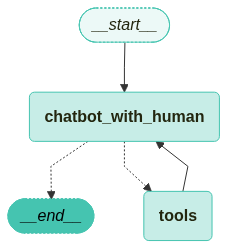

In [ ]:
# 도구 리스트 업데이트
tools_with_human = [human_assistance]

# 새로운 그래프 구성
graph_builder_hitl = StateGraph(State)

# LLM에 도구 바인딩
llm_with_human_tools = llm.bind_tools(tools_with_human)


def chatbot_with_human(state: State):
    """Human Interuption 요청할 수 있는 챗봇"""
    message = llm_with_human_tools.invoke(state["messages"])

    # interrupt 중 병렬 도구 호출 방지
    # (재개 시 도구 호출이 반복되는 것을 방지)
    if hasattr(message, "tool_calls"):
        assert (
            len(message.tool_calls) <= 1
        ), "병렬 도구 호출은 interrupt와 함께 사용할 수 없습니다"

    return {"messages": [message]} #append하기 위해 리스트로 감싼 건데, 우리는 annotated 해놨으니까. list로 안 감싸도 됨


# 노드 추가
graph_builder_hitl.add_node("chatbot_with_human", chatbot_with_human)

# ToolNode 추가
tool_node_hitl = ToolNode(tools=tools_with_human)
graph_builder_hitl.add_node("tools", tool_node_hitl)

# 엣지 추가
graph_builder_hitl.add_conditional_edges("chatbot_with_human", tools_condition)
graph_builder_hitl.add_edge("tools", "chatbot_with_human")
graph_builder_hitl.add_edge(START, "chatbot_with_human")

# 메모리와 함께 컴파일
memory_hitl = InMemorySaver()
graph_hitl = graph_builder_hitl.compile(checkpointer=memory_hitl)

# 그래프 시각화
visualize_graph(graph_hitl)

### HITL 테스트

사람에게 조언을 요청하는 질문으로 interrupt와 재개 흐름을 검증합니다. 그래프가 중단되면 `get_state`로 현재 상태를 확인하고, `Command(resume=...)`로 재개할 수 있습니다.

아래 코드는 인간 지원을 요청하는 메시지로 그래프를 실행합니다.

In [36]:
from langchain_teddynote.messages import random_uuid

# 인간 지원을 요청하는 메시지
user_input = "LangGraph 가 뭐야? 사람한테 듣고 싶어."
config_hitl = {"configurable": {"thread_id": random_uuid()}}

print(f"User: {user_input}\n")

stream_graph(
    graph_hitl,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=config_hitl,
)

User: LangGraph 가 뭐야? 사람한테 듣고 싶어.


🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [37]:
# 상태 확인 - 어느 노드에서 중단되었는지 확인
snapshot = graph_hitl.get_state(config_hitl)
print(f"\n현재 상태:")
print(f"  다음 실행할 노드: {snapshot.next}")
print(f"  체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")


현재 상태:
  다음 실행할 노드: ('tools',)
  체크포인트 ID: 1f1ba389-3247-6b32-8001-aebb9d7a45a7


In [38]:
# 인간의 응답으로 실행 재개
human_response = """## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)
"""

# Command 객체로 재개
human_command = Command(resume={"data": human_response})

print(f"\n사람의 응답: {human_response}\n")

# 재개
stream_graph(graph_hitl, inputs=human_command, config=config_hitl)


사람의 응답: ## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)



🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
사람한테 직접 물어본 답으로는, 받은 내용이 좀 부실했어요. 링크 추천만 왔고 정작 설명은 없었습니다.  
그래서 제가 사람에게 묻고 싶었던 의도를 살려, **사람이 설명하듯 쉽게** 말씀드릴게요.

### LangGraph가 뭐냐면
**LLM 앱을 “흐름도/상태머신”처럼 만들게 해주는 프레임워크**예요.

쉽게 말하면:

- 그냥 LLM 한 번 호출하고 끝나는 앱이 아니라
- **생각하고**
- **도구를 쓰고**
- **결과를 보고 다시 판단하고**
- **필요하면 반복하고**
- **중간 상태를 기억하는**

이런 **복잡한 AI 워크플로우**를 만들 때 쓰는 도구입니다.

---

### 왜 필요한데?
LangChain만으로도 체인을 만들 수는 있는데, 실제 에이전트 시스템은 보통 이렇게 흘러가요:

1. 사용자 질문 받음
2. 이 질문을 검색해야 할지 판단
3. 검색 수행
4. 결과가 부족하면 다시 검색
5. 충분하면 답변 생성
6. 사람 승인 받기
7. 최종 응답

이런 건 단순한 “한 줄 체인”보다  
**분기, 반복, 상태 저장**이 중요하거든요.

LangGraph는 이걸 **그

---

## 상태 커스터마이징

메시지 외에 업무 데이터를 다루는 커스텀 상태와 도구 기반 상태 업데이트를 도입합니다. `Command` 객체를 사용하면 도구 실행 결과로 상태를 직접 갱신할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Custom State Fields | messages 외에 추가 필드를 정의 |
| State Updates from Tools | 도구 결과로 상태를 직접 갱신 |
| Command(update=...) | 상태 업데이트를 지정하는 명령 객체 |

아래 코드는 `human_feedback` 필드가 추가된 커스텀 상태를 정의합니다.

In [39]:
from langchain.messages import ToolMessage
from langchain.tools import InjectedToolCallId


# 확장된 State 정의
class CustomState(TypedDict):
    """커스텀 필드가 추가된 상태"""

    messages: Annotated[list, add_messages]
    human_feedback: str  # 사람의 피드백

### 상태 업데이트 도구

도구 실행 결과를 `Command(update=...)`로 상태에 반영합니다. 이 패턴을 사용하면 도구가 단순히 문자열을 반환하는 것이 아니라, 상태의 특정 필드를 직접 수정할 수 있습니다.

아래 코드는 인간 검토를 요청하고 피드백에 따라 상태를 업데이트하는 도구를 정의합니다.

In [ ]:
@tool
def human_review(
    human_feedback, tool_call_id: Annotated[str, InjectedToolCallId]
     # 여기서의 human_feedback : AI가 사람에게 보여 주고 검토받을 내용
) -> str:
    """Request human review for information."""
    # 인간에게 검토 요청
    human_response = interrupt(
        {"question": "이 정보가 맞나요?", "human_feedback": human_feedback}
    )
    # 여기서의 human_feedback : AI가 사람에게 보여 주고 검토받을 내용
    # interrupt가 재개된 뒤,
    # human_response에는 사람이 실제로 입력한 응답이 들어 있음


    feedback = human_response.get("human_feedback", "")
    # feedback에는 사람이 쓴 수정 의견 문자열이 들어 있음

    if feedback.strip() == "":
        # 사용자가 AI 의 답변에 동의하는 경우
        return Command(
            update={
                "messages": [ToolMessage(human_response, tool_call_id=tool_call_id)]
            }
        )
    else:
        # 사용자가 AI 의 답변에 동의하지 않는 경우
        corrected_information = f"# 사용자에 의해 수정된 피드백: {feedback}"
        return Command(
            update={
                "messages": [ToolMessage(corrected_information, tool_call_id=tool_call_id)]
            }
        )

### 커스텀 상태 그래프

`CustomState`를 사용하여 그래프를 구성합니다. 기본 `State` 대신 커스텀 상태를 사용하면 애플리케이션에 필요한 추가 데이터를 관리할 수 있습니다.

아래 코드는 커스텀 상태와 `human_review` 도구를 사용하는 그래프를 구성합니다.

In [41]:
# 도구 리스트
tools_custom = [human_review]

# 새로운 그래프 구성
custom_graph_builder = StateGraph(CustomState)  # CustomState 사용

# LLM에 도구 바인딩
llm_with_custom_tools = llm.bind_tools(tools_custom)


def chatbot_custom(state: CustomState):
    """커스텀 상태를 사용하는 챗봇"""
    message = llm_with_custom_tools.invoke(state["messages"])

    if hasattr(message, "tool_calls"):
        assert len(message.tool_calls) <= 1

    return {"messages": [message]}


# 노드와 엣지 추가
custom_graph_builder.add_node("chatbot", chatbot_custom)
tool_node_custom = ToolNode(tools=tools_custom)
custom_graph_builder.add_node("tools", tool_node_custom)

custom_graph_builder.add_conditional_edges("chatbot", tools_condition)
custom_graph_builder.add_edge("tools", "chatbot")
custom_graph_builder.add_edge(START, "chatbot")

# 컴파일
memory_custom = InMemorySaver()
custom_graph = custom_graph_builder.compile(checkpointer=memory_custom)

### 그래프 시각화

커스텀 상태 그래프의 구조를 시각화합니다. 기본 도구 그래프와 동일한 구조이지만, 내부적으로 `CustomState`를 사용합니다.

아래 코드는 커스텀 상태 그래프를 시각화합니다.

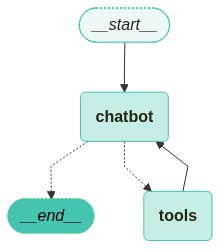

In [42]:
# 그래프 시각화
visualize_graph(custom_graph)

### 커스텀 상태 테스트

`human_review` 도구 호출 시 interrupt로 중단되고, 재개 시 사용자 피드백에 따라 상태가 갱신되는지 확인합니다. 사용자가 빈 피드백을 제공하면 AI의 답변에 동의하는 것으로 처리됩니다.

아래 코드는 인간 검토가 필요한 질문으로 그래프를 실행합니다.

In [43]:
# LangGraph의 출시일을 조사하고 검토 요청
user_input = (
    "2024년 노벨 문학상 수상자가 누구인지 조사해주세요. "
    "답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요."
)

custom_config = RunnableConfig(configurable={"thread_id": random_uuid()})

print(f"User: {user_input}\n")

# 실행 (interrupt에서 중단될 것임)
stream_graph(
    custom_graph,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=custom_config,
)

User: 2024년 노벨 문학상 수상자가 누구인지 조사해주세요. 답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요.


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [44]:
from langchain_teddynote.messages import display_message_tree

# 최신 메시지 가져오기
last_message = custom_graph.get_state(custom_config).values["messages"][-1]

# 최신 메시지 tree 구조로 표시
display_message_tree(last_message)

    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-5.4-2026-03-05", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--01a0e172-6c3f-7da3-a63c-83db03383b85"
    tool_calls:
        index [0]
            name: "human_review"
            args:
                human_feedback: {"query": "2024년 노벨 문학상 수상자 확인", "draft_answer": "2024년 노벨 문학상 수상자는 대한민국의 소설가 한강(Han Kang)입니다."}
            id: "call_iPPM9WpqhkqngzRtnlWPghOt"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 160
        output_tokens: 60
        total_tokens: 220
        input_token_details: {"audio": 0, "cache_read": 0}
        output_token_details: {"audio": 0, "reasoning": 0}


In [45]:
# AI 가 작성한 내용
print(last_message.tool_calls[0]["args"]["human_feedback"])

{'query': '2024년 노벨 문학상 수상자 확인', 'draft_answer': '2024년 노벨 문학상 수상자는 대한민국의 소설가 한강(Han Kang)입니다.'}


In [46]:
# 인간의 검토 응답으로 재개
human_command = Command(
    resume={"human_feedback": "2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다."}
)

stream_graph(custom_graph, inputs=human_command, config=custom_config)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 사용자에 의해 수정된 피드백: 2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
2024년 노벨 문학상 수상자는 대한민국의 작가 한강입니다.

---

## 상태 이력 관리

체크포인트 기반으로 상태를 저장/복원하여 롤백/재실행합니다. 이 기능을 통해 특정 시점으로 돌아가 다른 경로로 실행하거나, 실행 이력을 분석할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| State History | 그래프 실행 중 발생한 모든 상태 변경 이력 |
| Checkpoint ID | 특정 시점의 상태를 식별하는 고유 ID |
| Rollback | 지정한 체크포인트로 상태를 복원 |
| Resume | 복원된 상태에서 실행을 재개 |

아래 섹션에서는 체크포인트 기반 상태 관리를 실습합니다.

### 체크포인트 기반 그래프 구성

상태 이력 확인과 롤백/재실행을 위한 그래프를 구성합니다. Tavily 검색 도구를 사용하여 여러 번의 대화를 수행하고, 각 단계의 상태를 저장합니다.

아래 코드는 체크포인터가 연결된 검색 그래프를 구성합니다.

In [47]:
# 상태 관리 테스트를 위한 체크포인트 기반 그래프
graph_builder = StateGraph(State)

# 도구와 LLM 설정
tools = [TavilySearch(max_results=2)]
llm_with_tools_tt = llm.bind_tools(tools)


def chatbot_tt(state: State):
    """상태 관리 테스트용 챗봇"""
    return {"messages": [llm_with_tools_tt.invoke(state["messages"])]}


# 그래프 구성
graph_builder.add_node("chatbot", chatbot_tt)
tool_node_tt = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node_tt)

graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 메모리와 함께 컴파일
memory_tt = InMemorySaver()
time_travel_graph = graph_builder.compile(checkpointer=memory_tt)

### 그래프 시각화

체크포인트 기반 그래프의 구조를 확인합니다. 이전에 구성한 도구 그래프와 동일한 구조입니다.

아래 코드는 그래프를 시각화합니다.

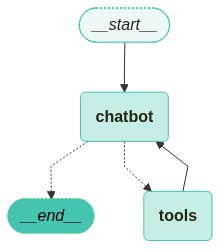

In [48]:
# 시각화
visualize_graph(time_travel_graph)

### 체크포인트 시퀀스 생성

여러 번 대화를 실행하여 상태 이력을 생성합니다. 각 실행마다 새로운 체크포인트가 생성되어 나중에 특정 시점으로 롤백할 수 있습니다.

아래 코드는 첫 번째 검색 대화를 실행합니다.

In [49]:
time_travel_config = RunnableConfig(configurable={"thread_id": "time-travel-1"})

# 첫 번째 대화
stream_graph(
    time_travel_graph,
    inputs={"messages": [HumanMessage(content="테디노트에 대해서 조사 좀 해주세요.")]},
    config=time_travel_config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트 TeddyNote 누구 무엇 하는 사람/브랜드 한국", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/channel/UCt2wAAXgm87ACiQnDHQEW6Q", "title": "테디노트 TeddyNote", "content": "데이터 분석, 머신러닝, 딥러닝, LLM 에 대한 내용을 다룹니다. 연구보다는 개발에 관심이 많습니다 ‍♂️ ...more 데이터 분석, 머신러닝, 딥러닝, LLM 에 대한", "score": 0.3887346, "raw_content": null, "id": "deb35d-00"}, {"url": "https://kr.linkedin.com/in/teddy-lee", "title": "Teddy Lee", "content": "# Teddy Lee\nLangChain\nSouth Korea, KR  \n500 connections, 10304 followers\n\n## About\n▶ 테디노트 YouTube & Blog ▶ LangChain Ambassador ▶ 랭체인 한국어 튜토리얼…\n\n## Experience\nN/A\n\n## Education\n### University of Wisconsin-Madison  \nN/A  \n2007 - 2013  \nNone\n\n## Publications\n테디노트의 랭체인을 활용한 RAG 비법노트: 심화편\n리코멘드 • Published on June 20, 2025\n\n테디노트의 랭체인을 활용한 RAG 비법노트: 기본편\n리코멘드 • Published on May

In [50]:
# 두 번째 대화
stream_graph(
    time_travel_graph,
    inputs={
        "messages": [HumanMessage(content="테디노트 온라인 강의 주소를 조사 해주세요.")]
    },
    config=time_travel_config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트 온라인 강의 주소 OR 테디노트 RAG 비법노트", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://fastcampus.co.kr/data_zero_teddy", "title": "[맛보기] 테디노트의 RAG 비법노트 : 랭체인 기반의 GPT·로컬 모델부터 LangGraph·Agent까지 | 패스트캠퍼스", "content": "Fast Campus Logo\n\nFast Campus\n\n## 사용자 메뉴\n\n커뮤니티기업교육\n\nCourse Cover Background Image\n\n관리RAG & AI Agent\n\n## [맛보기] 테디노트의 RAG 비법노트 : 랭체인 기반의 GPT·로컬 모델부터 LangGraph·Agent까지\n\n평생소장\n\n약 2시간\n\n누구나\n\nRAG 기본기부터 심화까지 제대로 끝내는 45시간 완성 로드맵, 테디노트의 '진짜' RAG 활용법! (본 상품의 미리보기 영상은 현재 판매 중인 원 강의의 일부 클립입니다.)\n\n#RAG#테디노트\n\n### 강의 정보\n\n온라인\n\n1클립\n\n25.08.28 전체 공개\n\n학습자료 제공\n\n### 100% 0원\n\n권장 소비자 가격\n:   ~~800,000원~~\n\n할인 금액\n:   -800,000원\n\n할인 판매가\n:   0원\n\n# 패스트캠퍼스\n\n## 테디노트\n\n## RAG\n\n본 페이지는 본 강의 수강 혜택 중 하나인 ‘주주총회 세미나’의 일부를 공개한 [맛보기 강의] 페이지입니다.\n\n최신 LangGraph 기능을 빠르게 익힐 수 있는 QuickTutoria

### 상태 이력 탐색

`get_state_history`로 전체 상태 이력을 조회하고 롤백할 체크포인트를 선택합니다. 이력은 최신순으로 반환되며, 각 체크포인트에는 해당 시점의 상태 정보가 포함됩니다.

아래 코드는 상태 이력을 조회하고 특정 조건(메시지 수가 6개)에 해당하는 체크포인트를 선택합니다.

In [64]:
# 전체 상태 히스토리 확인
print("상태 히스토리 (최신순):")
print("=" * 80)

# to_replay 변수 초기화
to_replay = None

for i, state in enumerate(time_travel_graph.get_state_history(time_travel_config)):
    print(f"\n[체크포인트 {i}]")
    print(f"  다음 노드: {state.next}")
    print(f"  체크포인트 ID: {state.config['configurable']['checkpoint_id']}")

    if len(state.values["messages"]) == 6 and to_replay is None:
        print("  이 상태로 되돌아갈 예정")
        display_message_tree(state.values["messages"][-1])
        to_replay = state


print("\n" + "=" * 80)

상태 히스토리 (최신순):

[체크포인트 0]
  다음 노드: ()
  체크포인트 ID: 1f1ba38a-f8dd-6497-800a-eecf8147254c

[체크포인트 1]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1ba38a-ba46-6de4-8009-e99c95630f58

[체크포인트 2]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1ba38a-8cf9-63c6-8008-2c4bf2de9242

[체크포인트 3]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1ba38a-7976-6204-8007-85a80c748d27

[체크포인트 4]
  다음 노드: ('__start__',)
  체크포인트 ID: 1f1ba38a-7971-63e7-8006-1495f6794179

[체크포인트 5]
  다음 노드: ()
  체크포인트 ID: 1f1ba38a-795b-67ca-8005-b16d281de516

[체크포인트 6]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1ba38a-2fb5-6593-8004-4bd4d0135e33

[체크포인트 7]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1ba38a-00e3-6e33-8003-5bc327ad2876

[체크포인트 8]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1ba389-ea49-6d8d-8002-76452a569afd

[체크포인트 9]
  다음 노드: ('tools',)
  체크포인트 ID: 1f1ba389-b925-6687-8001-224e8c010df7

[체크포인트 10]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f1ba389-ae47-67ae-8000-00f862febf2b

[체크포인트 11]
  다음 노드: ('__start__',)
  체크포인트 ID: 1f1ba389-ae45-6081-bfff-fc453aab6910



### 체크포인트로 롤백

선택한 체크포인트의 상태를 확인합니다. 이 시점의 마지막 메시지 내용을 표시하여 어느 지점으로 돌아갈지 확인할 수 있습니다.

아래 코드는 선택한 체크포인트의 마지막 메시지를 표시합니다.

In [65]:
display_message_tree(to_replay.values["messages"][-1])

AttributeError: 'NoneType' object has no attribute 'values'

### 상태 수정

복원된 상태에서 도구 호출 파라미터를 수정합니다. `update_tool_call` 함수를 사용하면 기존 도구 호출의 인자를 변경할 수 있어, 다른 검색어로 재실행할 수 있습니다.

아래 코드는 Tavily 검색 도구의 쿼리를 수정합니다.

In [ ]:
from langchain_teddynote.tools import update_tool_call

# 사용 예시:
updated_message = update_tool_call(
    to_replay.values["messages"][-1],
    tool_name="tavily_search",
    tool_args={"query": "테디노트 온라인 강의 site:naver.com", "search_depth": "basic"},
)

In [ ]:
updated_message

In [ ]:
# 변경하기 전의 message
display_message_tree(to_replay.values["messages"][-1])

In [ ]:
# 변경한 이후의 메시지 트리
display_message_tree(updated_message)

In [ ]:
# 변경된 메시지를 update_state 로 업데이트
updated_state = time_travel_graph.update_state(
    values={"messages": [updated_message]}, config=to_replay.config
)

### 수정 상태 재실행

업데이트된 상태로 그래프를 재실행하여 결과를 확인합니다. `update_state` 메서드로 상태를 수정하면 해당 시점부터 새로운 경로로 실행이 계속됩니다.

아래 코드는 수정된 검색 쿼리로 그래프를 재실행합니다.

In [ ]:
# 업데이트된 메시지를 스트리밍 합니다.
stream_graph(time_travel_graph, inputs=None, config=updated_state)